In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

In [3]:
# UCI Wine Quality dataset (red wine variant)
# Note: this file is semicolon-separated, not comma-separated
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
# Check target distribution — expect imbalance across quality scores
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [7]:
# ============================================================
# TARGET GROUPING
# ============================================================

In [8]:
# Original quality scores range 3-8, but extremes (3,4 and 7,8) have too
# few samples individually for reliable stratified CV and SMOTE.
# Grouping into 4 classes: keep 5 and 6 separate (they have enough data
# on their own), merge only the sparse tails.

def group_quality(q):
    if q <= 4:
        return 'low'
    elif q == 5:
        return 'medium'
    elif q == 6:
        return 'medium-high'
    else:
        return 'high'

df['quality_group'] = df['quality'].apply(group_quality)

df['quality_group'].value_counts()

quality_group
medium         681
medium-high    638
high           217
low             63
Name: count, dtype: int64

In [9]:
# ============================================================
# EDA — DESCRIPTIVE STATS & OUTLIER CHECK
# ============================================================

In [10]:
# Descriptive statistics for all numeric features
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


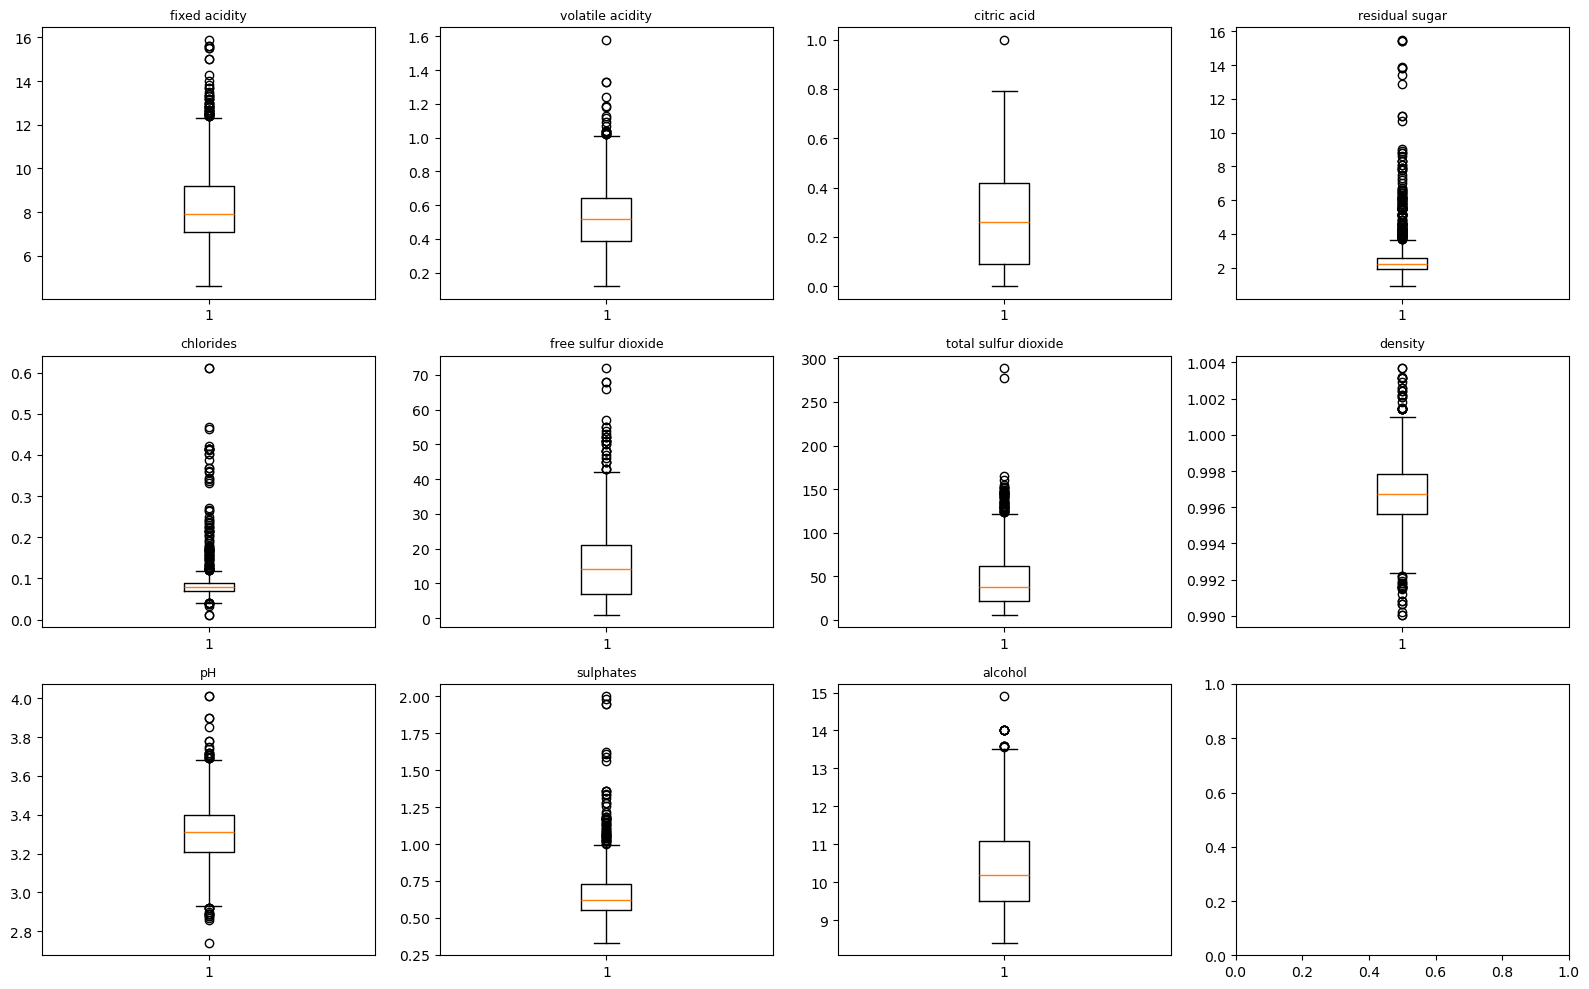

In [11]:
# Boxplots for outlier visualization (IQR-based)
fix,axes = plt.subplots(3,4, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-2]): # exclude quality, quality_group
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# IQR based outlier count per feature (for reference before deciding on capping)
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | ( series > upper)).sum()

for col in df.columns[:-2]:
    count = iqr_outlier_count(df[col])
    print(f"{col:25s}: {count:4d} outliers({count/len(df)*100:.1f}%)")

fixed acidity            :   49 outliers(3.1%)
volatile acidity         :   19 outliers(1.2%)
citric acid              :    1 outliers(0.1%)
residual sugar           :  155 outliers(9.7%)
chlorides                :  112 outliers(7.0%)
free sulfur dioxide      :   30 outliers(1.9%)
total sulfur dioxide     :   55 outliers(3.4%)
density                  :   45 outliers(2.8%)
pH                       :   35 outliers(2.2%)
sulphates                :   59 outliers(3.7%)
alcohol                  :   13 outliers(0.8%)


In [13]:
# ============================================================
# SKEWNESS CHECK — confirm natural right-skew on non-capped features
# ============================================================

In [14]:
from scipy.stats import skew

# Skewness: 0 = symmetric, >1 = highly right-skewed, <-1 = highly left-skewed
# This numerically confirms whether the boxplot patterns are mild natural
# variation or something that needs correction

for col in df.columns[:-2]:  # exclude quality, quality_group
    s = skew(df[col])
    print(f"{col:25s}: skew = {s:6.2f}")

fixed acidity            : skew =   0.98
volatile acidity         : skew =   0.67
citric acid              : skew =   0.32
residual sugar           : skew =   4.54
chlorides                : skew =   5.68
free sulfur dioxide      : skew =   1.25
total sulfur dioxide     : skew =   1.51
density                  : skew =   0.07
pH                       : skew =   0.19
sulphates                : skew =   2.43
alcohol                  : skew =   0.86


In [15]:
# ============================================================
# OUTLIER CAPPING (IQR) — residual sugar & chlorides only
# ============================================================

In [16]:
# These two features show the most aggressive right-skew and outlier
# concentration. Capping them reduces the influence of extreme values
# on AdaBoost, which is sensitive to noisy/outlier samples since
# misclassified points get exponentially upweighted each round.
# Other features are left untouched — their skew reflects natural
# chemical variation, not measurement error, and capping them risks
# losing signal for the already-sparse 'low' and 'high' quality groups.

def cap_outliers_iqr(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1 
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

for col in ["residual sugar", "chlorides", "sulphates"]:
    df = cap_outliers_iqr(df,col)

# Verify outlier count should now be 0 for these two

for col in ["residual sugar", "chlorides","sulphates"]:
    count= iqr_outlier_count(df[col])
    print(f"{col:25s} : {count:4d} outliers after capping")


residual sugar            :    0 outliers after capping
chlorides                 :    0 outliers after capping
sulphates                 :    0 outliers after capping


In [17]:
# ============================================================
# SKEWNESS RE-CHECK — after capping residual sugar, chlorides, sulphates
# ============================================================

In [18]:
for col in ['residual sugar', 'chlorides', 'sulphates']:
    s = skew(df[col])
    print(f"{col:25s}: skew = {s:6.2f}")

residual sugar           : skew =   0.86
chlorides                : skew =   0.43
sulphates                : skew =   0.78


In [19]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

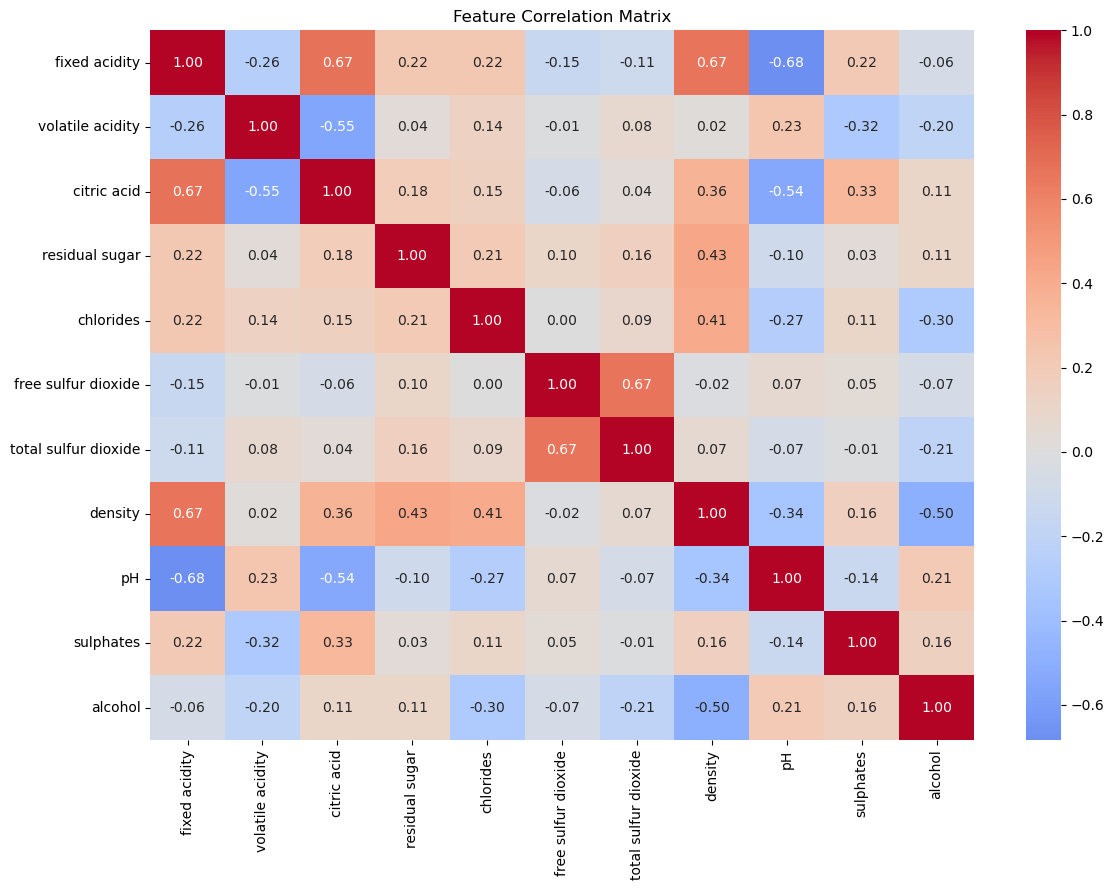

In [22]:
# Correlation matrix among numeric features(excluding target columns)
corr_matrix = df.drop(columns=["quality","quality_group"]).corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot= True, fmt= '.2f', cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# VIF — Variance Inflation Factor
# ============================================================

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["quality","quality_group"])

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data.sort_values("VIF", ascending=False)


,feature,VIF
7,density,1435.230635
8,pH,1032.689220
10,alcohol,129.685659
0,fixed acidity,71.458479
9,sulphates,28.505916
4,chlorides,28.349165
3,residual sugar,18.664058
1,volatile acidity,16.835214
2,citric acid,8.574945
6,total sulfur dioxide,6.495784


In [26]:
# ============================================================
# TARGET ENCODING & TRAIN/TEST SPLIT
# ============================================================

In [27]:
from sklearn.model_selection import train_test_split

# quality_group is ordinal in nature (low < medium < medium-high < high),
# but AdaBoostClassifier treats it as nominal multiclass — order
# isn't exploited by the algorithm. We keep labels as strings for now;
# encoding order is preserved manually for interpretability later.

X= df.drop(columns=["quality","quality_group"])
y= df["quality_group"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

X_train.shape

(1279, 11)

In [28]:
X_test.shape

(320, 11)

In [29]:
y_train.value_counts()

quality_group
medium         545
medium-high    510
high           174
low             50
Name: count, dtype: int64

In [30]:
# ============================================================
# SCALING DECISION
# ============================================================

In [31]:
# AdaBoost's default base estimator is a decision stump (depth-1 tree).
# Tree-based splits work on raw feature thresholds, not distances or
# gradients — so feature scale doesn't affect how splits are chosen.
# Scaling is therefore NOT required for AdaBoost with tree-based
# base estimators (same reasoning as Decision Tree / Random Forest).
# We skip StandardScaler here.

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
y_train.value_counts()

Before SMOTE:


quality_group
medium         545
medium-high    510
high           174
low             50
Name: count, dtype: int64

In [32]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)

print(f"After SMOTE:")
print(y_train_sm.value_counts())

After SMOTE:
quality_group
high           545
medium-high    545
medium         545
low            545
Name: count, dtype: int64


In [33]:
# ============================================================
# BASELINE MODEL — AdaBoostClassifier (default params)
# ============================================================

In [36]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.preprocessing import label_binarize

# Default base_estimator is a decision stump(max_depth=1)
ada_baseline = AdaBoostClassifier(random_state=42)
ada_baseline.fit(X_train_sm, y_train_sm)

y_pred = ada_baseline.predict(X_test)
y_pred_proba = ada_baseline.predict_proba(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        high       0.43      0.60      0.50        43
         low       0.15      0.31      0.21        13
      medium       0.68      0.62      0.65       136
 medium-high       0.57      0.48      0.52       128

    accuracy                           0.55       320
   macro avg       0.46      0.51      0.47       320
weighted avg       0.58      0.55      0.56       320



In [38]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

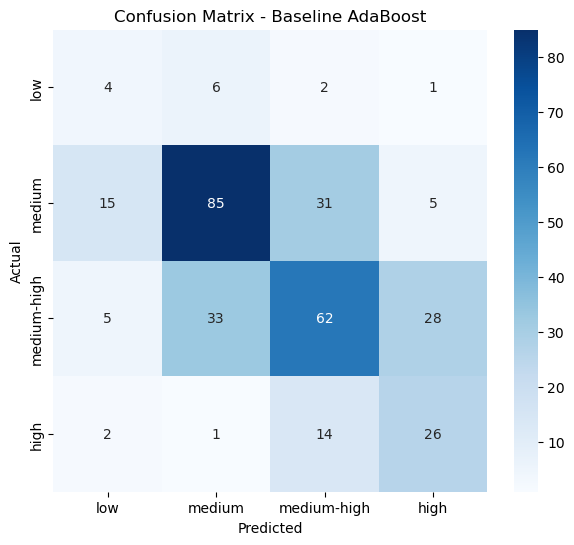

In [45]:
labels = ["low","medium","medium-high","high"]
cm = confusion_matrix(y_test,y_pred, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues",xticklabels=labels,yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline AdaBoost")
plt.show()

In [47]:
# ============================================================
# HYPERPARAMETER TUNING — GridSearchCV
# ============================================================

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [51]:
# Default base estimator is a decision stump (max_depth=1) — too weak to
# capture the subtle boundary between adjacent quality groups. We widen
# the search to slightly deeper stumps (max_depth=2,3) to let each weak
# learner pick up a bit more signal before boosting corrects the rest.

param_grid = {
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=42),
                  DecisionTreeClassifier(max_depth=2, random_state=42),
                  DecisionTreeClassifier(max_depth=3, random_state=42)],
    "n_estimators": [50,100,200],
    "learning_rate": [0.1, 0.5, 1.0]
}


ada = AdaBoostClassifier(random_state=42)

grid_search = GridSearchCV(ada,param_grid,cv=5, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_search.fit(X_train_sm, y_train_sm)

print("Best params:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'estimator': DecisionTreeClassifier(max_depth=3, random_state=42), 'learning_rate': 0.5, 'n_estimators': 200}
Best CV F1 score: 0.6972873845052582


In [52]:
# ============================================================
# BEST MODEL — EVALUATION ON TEST SET
# ============================================================

In [53]:
best_ada = grid_search.best_estimator_
y_pred_best = best_ada.predict(X_test)

print("Test set performance (best model):")
print(classification_report(y_test,y_pred_best))

Test set performance (best model):
              precision    recall  f1-score   support

        high       0.48      0.70      0.57        43
         low       0.21      0.23      0.22        13
      medium       0.69      0.63      0.66       136
 medium-high       0.54      0.50      0.52       128

    accuracy                           0.57       320
   macro avg       0.48      0.52      0.49       320
weighted avg       0.58      0.57      0.57       320



In [54]:
# ============================================================
# OVERFIT CHECK — Train vs Test
# ============================================================

In [57]:
from sklearn.metrics import f1_score

train_f1 = f1_score(y_train_sm, best_ada.predict(X_train_sm), average="macro")
test_f1 = f1_score(y_test, y_pred_best, average="macro")

print(f"Train (SMOTE) F1 macro: {train_f1:.3f}")
print(f"Test F1 macro: {test_f1:.3f}")
print(f"Gap:  {train_f1 - test_f1:.3f}")

Train (SMOTE) F1 macro: 0.806
Test F1 macro: 0.492
Gap:  0.314


In [58]:
# ============================================================
# OVERFIT REDUCTION — try max_depth=2 as a middle ground
# ============================================================

In [59]:
ada_depth2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada_depth2.fit(X_train_sm, y_train_sm)

train_f1_d2 = f1_score(y_train_sm, ada_depth2.predict(X_train_sm), average='macro')
test_f1_d2 = f1_score(y_test, ada_depth2.predict(X_test), average='macro')

print(f"max_depth=2 — Train F1: {train_f1_d2:.3f}, Test F1: {test_f1_d2:.3f}, Gap: {train_f1_d2 - test_f1_d2:.3f}")

max_depth=2 — Train F1: 0.692, Test F1: 0.468, Gap: 0.224


In [60]:
# ============================================================
# FEATURE IMPORTANCE — MDI (Mean Decrease in Impurity)
# ============================================================

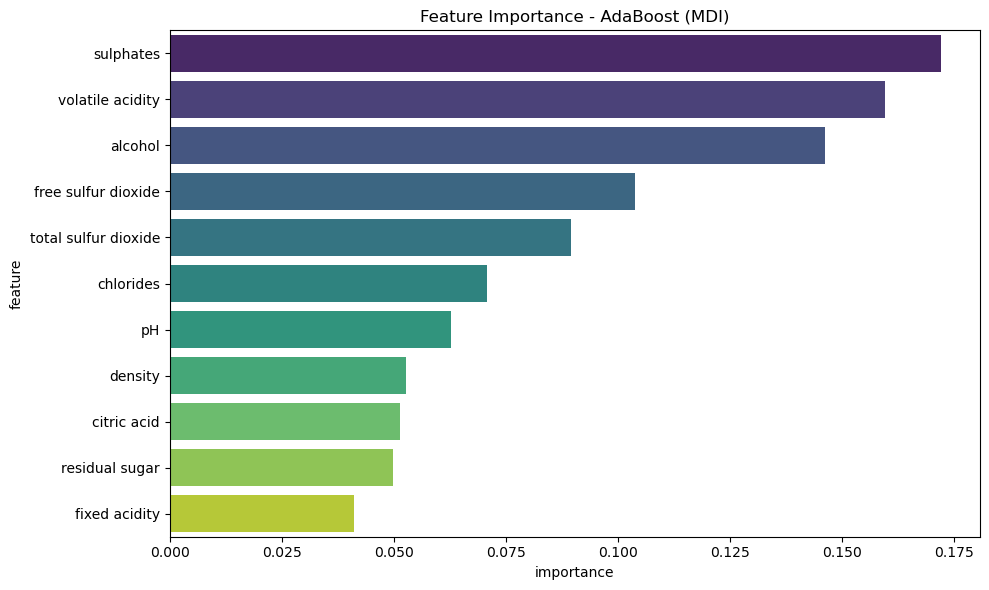

In [64]:
importances = best_ada.feature_importances_
feat_imp = pd.DataFrame({
    "feature":X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title("Feature Importance - AdaBoost (MDI)")
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# ROC-AUC — Multiclass (One-vs-Rest)
# ============================================================

In [71]:
from sklearn.preprocessing import label_binarize

model_classes = best_ada.classes_
print("Model's classes order:", model_classes)

y_test_bin = label_binarize(y_test, classes=model_classes)
y_pred_proba_best = best_ada.predict_proba(X_test)

# roc_auc_score with multi_class="ovr" handles multiclass directly
roc_auc_ovr = roc_auc_score(y_test_bin, y_pred_proba_best, multi_class="ovr", average="macro")
print(f"\nROC_AUC (macro, OvR): {roc_auc_ovr:.3f}")

# Pre-class AUC for more detail
for i, cls in enumerate(classes):
    auc_cls = roc_auc_score(y_test_bin[:,i], y_pred_proba_best[:,i])
    print(f" {cls:15s}: AUC = {auc_cls:.3f}")

Model's classes order: ['high' 'low' 'medium' 'medium-high']

ROC_AUC (macro, OvR): 0.748
 low            : AUC = 0.877
 medium         : AUC = 0.759
 medium-high    : AUC = 0.782
 high           : AUC = 0.576


In [72]:
# ============================================================
# CV MEAN ± STD — for the tuned model
# ============================================================

In [73]:
from sklearn.model_selection import cross_val_score

In [74]:
cv_scores = cross_val_score(best_ada, X_train_sm, y_train_sm, cv=5, scoring="f1_macro", n_jobs=-1)
print(f"CV F1 macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} ")

CV F1 macro: 0.697 ± 0.037 


In [75]:
# ============================================================
# COHEN'S KAPPA & LOG LOSS
# ============================================================

In [76]:
from sklearn.metrics import cohen_kappa_score, log_loss

In [78]:
kappa = cohen_kappa_score(y_test,y_pred_best)
logloss = log_loss(y_test,y_pred_proba_best, labels= model_classes)

print(f"Cohen's Kappa {kappa:.3f}")
print(f"Log Loss: {logloss:.3f}")

Cohen's Kappa 0.350
Log Loss: 1.347


In [79]:
# ============================================================
# CONFUSION MATRIX — Tuned Model
# ============================================================

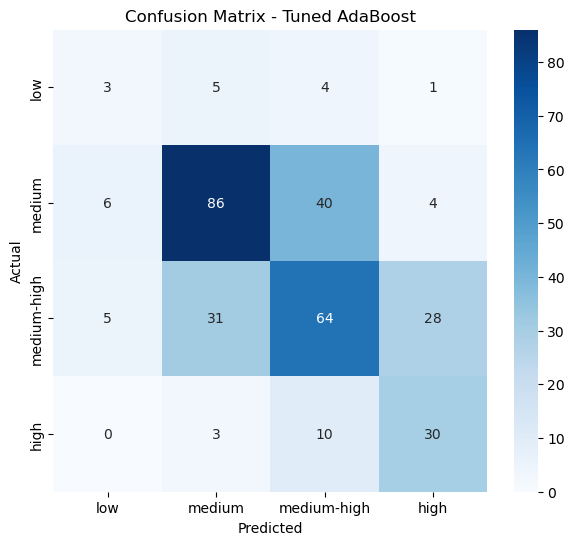

In [80]:
cm_tuned = confusion_matrix(y_test,y_pred_best, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned AdaBoost")
plt.show()